# Summer of Code - Artificial Intelligence

## Week 08: Deep Learning

### Day 05: Training Deep Neural Networks

In this notebook, we will learn the theoretical foundations of **training deep neural networks** using **TensorFlow** and the **Sequential API**.


# The Vanishing and Exploding Gradient Problem

When training deep neural networks, we often encounter the **vanishing and exploding gradient problem**. This occurs when the gradients of the loss function with respect to the weights become very small (vanish) or very large (explode) as they are propagated back through the layers of the network during backpropagation. This can lead to slow convergence or divergence during training.

<img src='sigmoid.png' width='400'>

## Better Weight Initialization
To mitigate the vanishing and exploding gradient problem, we can use better weight initialization techniques. One common approach is to use **Xavier initialization** (also known as Glorot initialization) for layers with sigmoid or tanh activation functions, and **He initialization** for layers with ReLU activation functions.

## Better Activation Functions
Another way to address the vanishing gradient problem is to use activation functions that do not saturate, such as the **ReLU (Rectified Linear Unit)** activation function. ReLU allows gradients to flow more easily through the network, which helps in training deep networks. However, ReLU can suffer from the **dying ReLU** problem, where neurons can become inactive and only output zero. To mitigate this, we can use variants like **Leaky ReLU** or **Parametric ReLU**.

<img src='leaky_relu.png' width='400'>

## Batch Normalization
Another effective technique to combat the vanishing and exploding gradient problem is **Batch Normalization**. This technique normalizes the inputs of each layer to have a mean of zero and a variance of one, which helps stabilize the learning process and allows for higher learning rates.

<img src='b_norm.png' width='700'>

# Reusing Pretrained Layers
In deep learning, it is common to reuse layers from pretrained models. This technique, known as **transfer learning**, allows us to leverage the knowledge learned by a model on a large dataset and apply it to a different but related task. By reusing pretrained layers, we can often achieve better performance with less training data and computational resources.

<img src='pretrained_layers.png' width='500'>


# Dropout
Dropout is a regularization technique used to prevent overfitting in deep neural networks. During training, dropout randomly sets a fraction of the input units to zero at each update step, which helps to break up co-adaptations among neurons. This encourages the network to learn more robust features that are useful in conjunction with many different random subsets of the other neurons.

<img src='dropout.png' width='300'>

# Learning Rate Scheduling
Learning rate scheduling is a technique used to adjust the learning rate during training. By reducing the learning rate as training progresses, we can help the model converge more smoothly and avoid overshooting minima in the loss landscape. Common learning rate scheduling methods include step decay, exponential decay, and cosine annealing.

<img src='lr_schedulers.png' width='500'>

In [ ]:
import tensorflow as tf

# Check GPU availability
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: []


## Load and Prepare CIFAR-10 Dataset
We'll use data augmentation for the training set to improve generalization.

In [2]:
import numpy as np

# Load CIFAR-10 dataset directly from Keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Train samples: {x_train.shape}, Test samples: {x_test.shape}")
print(f"Classes: {classes}")

Train samples: (50000, 32, 32, 3), Test samples: (10000, 32, 32, 3)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


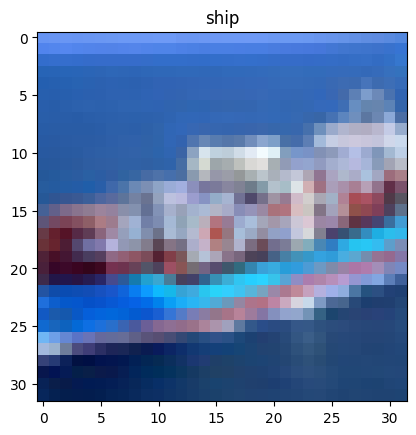

In [31]:
import matplotlib.pyplot as plt
import numpy as np

index = np.random.randint(0,len(x_train))

plt.imshow(x_train[index])
plt.title(classes[y_train[index][0]])
plt.show()

In [32]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [34]:
# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# CIFAR-10 mean and std per channel (same values as the PyTorch version)
mean = np.array([0.4914, 0.4822, 0.4465], dtype="float32")
std  = np.array([0.2023, 0.1994, 0.2010], dtype="float32")

x_train = (x_train - mean) / std
x_test  = (x_test  - mean) / std

# Convert labels to integers (remove the extra dimension)
y_train = y_train.flatten()
y_test  = y_test.flatten()

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape},  y_test:  {y_test.shape}")

x_train: (50000, 32, 32, 3), y_train: (50000,)
x_test:  (10000, 32, 32, 3),  y_test:  (10000,)


In [35]:
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [36]:
# Build tf.data pipelines with data augmentation for training
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Data augmentation layer (applied only during training)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
], name="data_augmentation")

def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label

train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(buffer_size=10_000)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"Train batches: {len(train_dataset)}, Test batches: {len(test_dataset)}")

Train batches: 1563, Test batches: 313


## Transfer Learning: Load Pretrained ResNet50V2
We'll use a pretrained ResNet50V2 model (ImageNet weights) and fine-tune it for CIFAR-10. We'll:
- Freeze the base model (feature extraction)
- Add a custom classification head with Dropout for regularization
- Use the **Sequential API** to assemble the full model

In [37]:
# Load ResNet50V2 pretrained on ImageNet, without the top classifier
base_model = tf.keras.applications.ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(32, 32, 3),
    pooling="avg",   # Global Average Pooling at the output
)

# Freeze the base model weights (feature extraction stage)
base_model.trainable = False

print(f"Base model parameters: {base_model.count_params():,}")
print(f"Trainable parameters:  {sum([tf.size(w).numpy() for w in base_model.trainable_weights]):,}")

Base model parameters: 23,564,800
Trainable parameters:  0


In [38]:
# Build the full model using the Sequential API
model = tf.keras.Sequential([
    # Pretrained feature extractor (frozen)
    base_model,

    # Dropout for regularization
    tf.keras.layers.Dropout(0.2),

    # Final classification layer (10 CIFAR-10 classes)
    tf.keras.layers.Dense(10, activation="softmax"),
], name="resnet50v2_cifar10")

model.summary()

Model: "resnet50v2_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 2048)           │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,585,290 (89.97 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

## Setup Training with Learning Rate Scheduler

In [39]:
# Learning rate scheduler: step decay — reduce by 0.1 every 5 epochs
def step_decay_schedule(epoch, lr):
    if epoch > 0 and epoch % 5 == 0:
        return lr * 0.1
    return lr

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(step_decay_schedule, verbose=0)

# Compile the model
INITIAL_LR = 0.001

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

print(f"Initial learning rate: {model.optimizer.learning_rate.numpy():.6f}")

Initial learning rate: 0.001000


## Training Loop
Train the model for several epochs, tracking loss and accuracy.

In [40]:
# Train the model
NUM_EPOCHS = 10

history = model.fit(
    train_dataset,
    epochs=NUM_EPOCHS,
    validation_data=test_dataset,
    callbacks=[lr_scheduler],
    verbose=1,
)

print("\nTraining completed!")
print(f"Final Test Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 264s 158ms/step - accuracy: 0.1212 - loss: 4.0334 - val_accuracy: 0.1334 - val_loss: 2.8606 - learning_rate: 0.0010
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 230s 147ms/step - accuracy: 0.1366 - loss: 2.7484 - val_accuracy: 0.1360 - val_loss: 2.6246 - learning_rate: 0.0010
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 368s 236ms/step - accuracy: 0.1395 - loss: 2.7382 - val_accuracy: 0.1314 - val_loss: 2.9092 - learning_rate: 0.0010
Epoch 4/10
 583/1563 ━━━━━━━━━━━━━━━━━━━━ 1:45 108ms/step - accuracy: 0.1430 - loss: 2.6968

KeyboardInterrupt: 

## Visualize Training Progress
Plot the training/test loss, accuracy, and learning rate schedule.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

train_losses = history.history["loss"]
test_losses  = history.history["val_loss"]
train_accs   = [a * 100 for a in history.history["accuracy"]]
test_accs    = [a * 100 for a in history.history["val_accuracy"]]
learning_rates = history.history["lr"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss plot
axes[0].plot(train_losses, label="Train Loss", marker="o")
axes[0].plot(test_losses,  label="Test Loss",  marker="s")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Test Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, label="Train Accuracy", marker="o")
axes[1].plot(test_accs,  label="Test Accuracy",  marker="s")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Training and Test Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate schedule
axes[2].plot(learning_rates, marker="o", color="green")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Test Accuracy: {test_accs[-1]:.2f}%")